# Atividade 1 — Segmentação de clientes

Base: [Online Retail, da UCI](https://archive.ics.uci.edu/dataset/352/online+retail). Os valores estão em libras (£). A ideia é montar grupos de clientes com recência, frequência e gasto (RFM) e comparar três formas de agrupamento: K-Means, hierárquico e DBSCAN.

**Para rodar no Colab:** abra este arquivo e clique em **Ambiente de execução → Executar tudo**. A primeira célula instala as bibliotecas e a base é baixada automaticamente. Na primeira vez, a leitura do Excel pode demorar alguns minutos.

O relatório está no fim do notebook.

In [1]:
# Preparação do ambiente no Google Colab (execute antes das demais células).
import subprocess
import sys

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy>=1.26', 'pandas>=2.2', 'scipy>=1.12',
    'scikit-learn>=1.4', 'matplotlib>=3.8', 'seaborn>=0.13',
    'plotly>=5.20', 'openpyxl>=3.1'
])
print('Ambiente pronto. A próxima célula baixará a base, se necessário.')


Ambiente pronto. A próxima célula baixará a base, se necessário.


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()

import io, time, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from IPython.display import display

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 20)
print('pandas', pd.__version__, '| scikit-learn importado | seed', SEED)

pandas 2.2.3 | scikit-learn importado | seed 42


## 1. Dados e limpeza

Cada linha é um produto de uma fatura. Para montar o RFM por cliente, saem cancelamentos, registros sem `CustomerID` e linhas com quantidade ou preço não positivos.

In [3]:
DATA = ROOT / 'apres_mod2' / 'online_retail_uci.zip'
if not DATA.exists():
    DATA.parent.mkdir(parents=True, exist_ok=True)
    url = 'https://archive.ics.uci.edu/static/public/352/online%2Bretail.zip'
    urllib.request.urlretrieve(url, DATA)
with zipfile.ZipFile(DATA) as z:
    raw = pd.read_excel(io.BytesIO(z.read('Online Retail.xlsx')), engine='openpyxl')
raw['InvoiceNo'] = raw['InvoiceNo'].astype(str)
raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'], errors='coerce')
auditoria = pd.Series({
    'linhas originais': len(raw),
    'sem CustomerID': int(raw.CustomerID.isna().sum()),
    'faturas de cancelamento': int(raw.InvoiceNo.str.upper().str.startswith('C').sum()),
    'quantidade não positiva': int((raw.Quantity <= 0).sum()),
    'preço não positivo': int((raw.UnitPrice <= 0).sum()),
    'data inválida': int(raw.InvoiceDate.isna().sum()),
})
display(auditoria.to_frame('linhas'))
print('Período:', raw.InvoiceDate.min().date(), 'a', raw.InvoiceDate.max().date())

,linhas
linhas originais,541909
sem CustomerID,135080
faturas de cancelamento,9288
quantidade não positiva,10624
preço não positivo,2517
data inválida,0


Período: 2010-12-01 a 2011-12-09


In [4]:
compras = raw.loc[
    raw.CustomerID.notna() & raw.InvoiceDate.notna()
    & ~raw.InvoiceNo.str.upper().str.startswith('C')
    & (raw.Quantity > 0) & (raw.UnitPrice > 0)
].copy()
compras['CustomerID'] = compras.CustomerID.astype(int)
compras['Revenue'] = compras.Quantity * compras.UnitPrice
data_referencia = compras.InvoiceDate.max().normalize() + pd.Timedelta(days=1)
rfm = compras.groupby('CustomerID').agg(
    recencia_dias=('InvoiceDate', lambda x: (data_referencia - x.max().normalize()).days),
    frequencia_faturas=('InvoiceNo', 'nunique'),
    valor_gasto=('Revenue', 'sum'),
)
FEATURES = ['recencia_dias', 'frequencia_faturas', 'valor_gasto']
print(f'{len(compras):,} linhas válidas; {len(rfm):,} clientes; receita histórica £{rfm.valor_gasto.sum():,.2f}')
print('Data de referência:', data_referencia.date())
display(rfm.describe(percentiles=[.25, .50, .75, .90, .99]).round(2))

397,884 linhas válidas; 4,338 clientes; receita histórica £8,911,407.90
Data de referência: 2011-12-10


,recencia_dias,frequencia_faturas,valor_gasto
count,4338.00,4338.00,4338.00
mean,93.06,4.27,2054.27
std,100.01,7.70,8989.23
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.75,5.00,1661.74
90%,263.30,9.00,3646.53
99%,369.63,30.00,19881.00
max,374.00,209.00,280206.02


## 2. Variáveis para o agrupamento

Recência é o número de dias desde a última compra; frequência conta faturas; valor é o total gasto. Como frequência e gasto têm valores extremos, usei `log1p`, um teto no percentil 99 e `StandardScaler` antes dos algoritmos. O valor original continua nas tabelas de resultado.

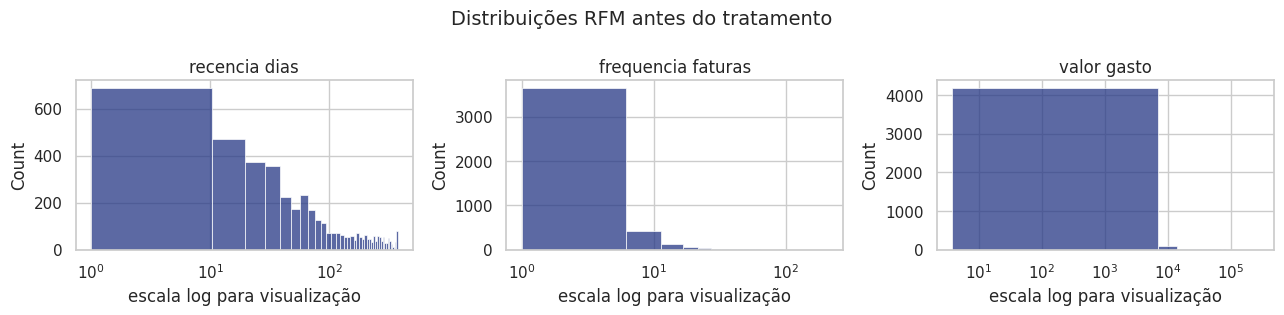

In [5]:
limites_99 = rfm[FEATURES].quantile(.99)
X_log = np.log1p(rfm[FEATURES].clip(upper=limites_99, axis=1))
escalador = StandardScaler()
X = escalador.fit_transform(X_log)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, coluna in zip(axes, FEATURES):
    sns.histplot(rfm[coluna], ax=ax, bins=40, color='#253785')
    ax.set_xscale('log')
    ax.set_title(coluna.replace('_', ' '))
    ax.set_xlabel('escala log para visualização')
plt.suptitle('Distribuições RFM antes do tratamento', fontsize=14)
plt.tight_layout(); plt.show()

## 3. K-Means

O cotovelo e a silhueta ajudam a comparar valores de `k`. Também verifico quantas iterações o algoritmo usou e se o resultado muda com outras inicializações.

,k,inercia,iteracoes,tempo_s,silhueta,davies_bouldin,calinski_harabasz
0,2,6344.702,5,0.083,0.429,0.884,4557.851
1,3,4737.574,11,0.097,0.327,1.054,3786.631
2,4,3796.754,16,0.124,0.332,1.019,3507.193
3,5,3167.687,13,0.142,0.318,0.989,3367.181
4,6,2730.910,29,0.182,0.315,1.013,3262.384
5,7,2444.250,19,0.170,0.305,0.992,3121.447
6,8,2239.543,29,0.202,0.300,0.993,2975.979


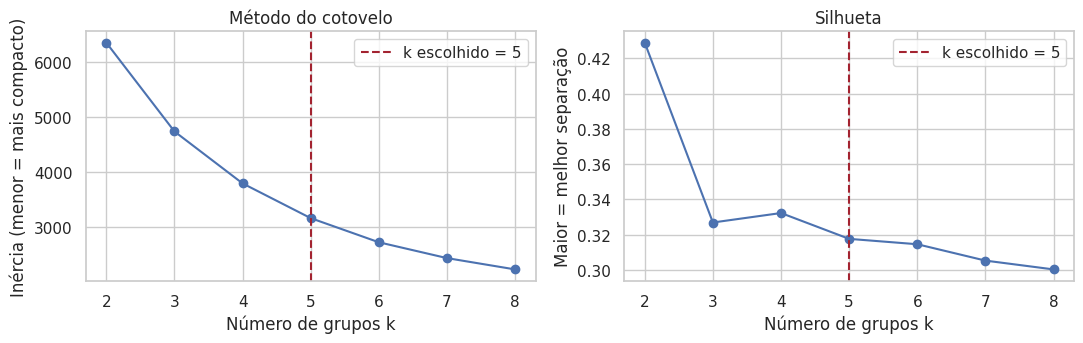

In [6]:
def avaliar(X, rotulos, amostra=1500):
    rotulos = np.asarray(rotulos)
    valido = rotulos != -1
    grupos = np.unique(rotulos[valido])
    if len(grupos) < 2 or valido.sum() <= len(grupos):
        return {'silhueta': np.nan, 'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan}
    Y, y = X[valido], rotulos[valido]
    return {
        'silhueta': silhouette_score(Y, y, sample_size=min(amostra, len(Y)), random_state=SEED),
        'davies_bouldin': davies_bouldin_score(Y, y),
        'calinski_harabasz': calinski_harabasz_score(Y, y),
    }

linhas_k = []
for k in range(2, 9):
    inicio = time.perf_counter()
    modelo = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X)
    linhas_k.append({'k': k, 'inercia': modelo.inertia_, 'iteracoes': modelo.n_iter_,
                     'tempo_s': time.perf_counter()-inicio,
                     **avaliar(X, modelo.labels_)})
km_grid = pd.DataFrame(linhas_k)
display(km_grid.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(km_grid.k, km_grid.inercia, 'o-'); axes[0].set_title('Método do cotovelo')
axes[0].set_ylabel('Inércia (menor = mais compacto)')
axes[1].plot(km_grid.k, km_grid.silhueta, 'o-'); axes[1].set_title('Silhueta')
axes[1].set_ylabel('Maior = melhor separação')
for ax in axes:
    ax.set_xlabel('Número de grupos k'); ax.axvline(5, color='#A32330', ls='--', label='k escolhido = 5')
    ax.legend()
plt.tight_layout(); plt.show()

In [7]:
K_FINAL = 5
inicio = time.perf_counter()
km = KMeans(n_clusters=K_FINAL, n_init=20, random_state=SEED).fit(X)
tempo_km = time.perf_counter() - inicio
referencia = km.labels_
estabilidade = pd.DataFrame([
    {'seed': s,
     'ARI_vs_referencia': adjusted_rand_score(
         referencia, KMeans(n_clusters=K_FINAL, n_init=1, random_state=s).fit_predict(X))}
    for s in range(10)
])
print('Convergência:', km.n_iter_, 'iterações (limite padrão: 300)')
print('ARI de estabilidade em 10 inicializações:',
      f'mediana {estabilidade.ARI_vs_referencia.median():.3f};',
      f'mínimo {estabilidade.ARI_vs_referencia.min():.3f}')
display(estabilidade.round(3))

Convergência: 13 iterações (limite padrão: 300)
ARI de estabilidade em 10 inicializações: mediana 0.974; mínimo 0.914


,seed,ARI_vs_referencia
0,0,0.971
1,1,0.985
2,2,0.985
3,3,0.968
4,4,0.914
5,5,0.975
6,6,0.972
7,7,0.974
8,8,0.989
9,9,0.990


## 4. Hierárquico

Testei Ward, complete e average. O dendrograma abaixo usa 400 clientes para caber na tela; a tabela de métricas usa a base inteira.

,linkage,k,tempo_s,menor_grupo,silhueta,davies_bouldin,calinski_harabasz
0,ward,3,1.066,693,0.292,1.093,3127.463
1,ward,4,0.963,693,0.266,1.119,2951.999
2,ward,5,0.689,693,0.269,1.102,2830.679
3,complete,3,0.676,1015,0.191,1.305,2316.553
4,complete,4,0.696,891,0.212,1.257,2436.099
5,complete,5,0.710,235,0.178,1.290,2157.875
6,average,3,0.721,4,0.348,0.665,917.843
7,average,4,0.737,1,0.348,0.582,613.806
8,average,5,0.731,1,0.307,0.565,462.579


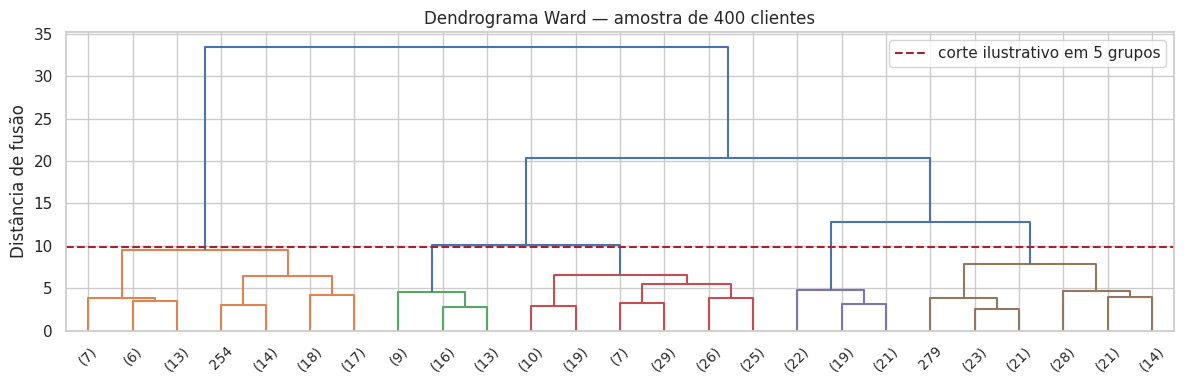

In [8]:
linhas_h = []
for metodo in ['ward', 'complete', 'average']:
    for k in [3, 4, 5]:
        inicio = time.perf_counter()
        lab = AgglomerativeClustering(n_clusters=k, linkage=metodo).fit_predict(X)
        linhas_h.append({'linkage': metodo, 'k': k, 'tempo_s': time.perf_counter()-inicio,
                         'menor_grupo': np.bincount(lab).min(), **avaliar(X, lab)})
hier_grid = pd.DataFrame(linhas_h)
display(hier_grid.round(3))

rng = np.random.default_rng(SEED)
ids_amostra = rng.choice(len(X), 400, replace=False)
arvore = linkage(X[ids_amostra], method='ward')
altura_corte = (arvore[-5, 2] + arvore[-4, 2]) / 2
plt.figure(figsize=(12, 4))
dendrogram(arvore, truncate_mode='lastp', p=25, show_leaf_counts=True,
           color_threshold=altura_corte)
plt.axhline(altura_corte, color='#A32330', ls='--', label='corte ilustrativo em 5 grupos')
plt.title('Dendrograma Ward — amostra de 400 clientes')
plt.ylabel('Distância de fusão'); plt.legend(); plt.tight_layout(); plt.show()

## 5. DBSCAN

O gráfico mostra a distância até o 20º vizinho. Testei alguns raios a partir dele e anotei quantos clientes ficaram como ruído (`-1`).

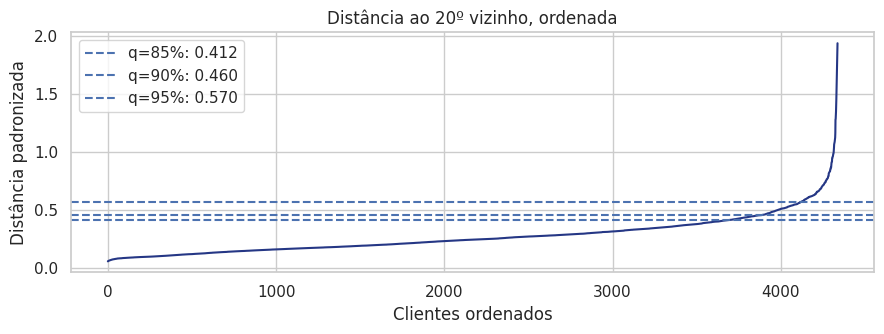

,min_samples,quantil,eps,n_clusters,ruido_pct,menor_grupo,tempo_s,silhueta,davies_bouldin,calinski_harabasz
0,10,0.85,0.314,6,7.538,10,0.067,0.129,1.655,1285.226
1,10,0.90,0.361,3,4.149,810,0.083,0.165,1.653,2145.682
2,10,0.95,0.452,2,1.729,1474,0.096,0.291,1.044,2437.224
3,20,0.85,0.412,4,5.671,43,0.071,0.170,1.339,1717.668
4,20,0.90,0.460,2,2.928,1458,0.101,0.299,1.035,2454.042
5,20,0.95,0.570,2,1.083,1476,0.115,0.285,1.047,2428.736


In [9]:
MS = 20
dist_20 = NearestNeighbors(n_neighbors=MS).fit(X).kneighbors(X)[0][:, -1]
quantis = [.85, .90, .95]
plt.figure(figsize=(9, 3.5))
plt.plot(np.sort(dist_20), color='#253785')
for q in quantis:
    plt.axhline(np.quantile(dist_20, q), ls='--', label=f'q={q:.0%}: {np.quantile(dist_20,q):.3f}')
plt.title('Distância ao 20º vizinho, ordenada')
plt.xlabel('Clientes ordenados'); plt.ylabel('Distância padronizada')
plt.legend(); plt.tight_layout(); plt.show()

linhas_db = []
for min_pts in [10, 20]:
    dist = NearestNeighbors(n_neighbors=min_pts).fit(X).kneighbors(X)[0][:, -1]
    for q in quantis:
        eps = float(np.quantile(dist, q))
        inicio = time.perf_counter()
        lab = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
        grupos = np.unique(lab[lab != -1])
        tamanhos = pd.Series(lab[lab != -1]).value_counts()
        linhas_db.append({'min_samples': min_pts, 'quantil': q, 'eps': eps,
                          'n_clusters': len(grupos), 'ruido_pct': 100*(lab == -1).mean(),
                          'menor_grupo': int(tamanhos.min()) if len(tamanhos) else 0,
                          'tempo_s': time.perf_counter()-inicio,
                          **avaliar(X, lab)})
db_grid = pd.DataFrame(linhas_db)
display(db_grid.round(3))
EPS_FINAL = float(np.quantile(dist_20, .85))
inicio = time.perf_counter()
db_labels = DBSCAN(eps=EPS_FINAL, min_samples=20).fit_predict(X)
tempo_db = time.perf_counter() - inicio

## 6. Comparação

O K-Means com `k=2` teve a maior silhueta (0,429), mas separou a base em grupos muito amplos. Para a análise de clientes, usei `k=5`: a silhueta cai para 0,318, porém os perfis ficam mais fáceis de diferenciar. Ward e DBSCAN ficam na tabela para comparação. No DBSCAN, a silhueta desconsidera os pontos marcados como ruído.

In [10]:
inicio = time.perf_counter()
hier_labels = AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X)
tempo_hier = time.perf_counter() - inicio

def linha_comparacao(nome, lab, tempo):
    grupos = pd.Series(lab[lab != -1]).value_counts()
    return {'algoritmo': nome, 'n_clusters': len(grupos),
            'ruido_pct': 100*(lab == -1).mean(),
            'menor_grupo': int(grupos.min()) if len(grupos) else 0,
            'tempo_s': tempo, **avaliar(X, lab)}

comparacao = pd.DataFrame([
    linha_comparacao('K-Means (k=5)', km.labels_, tempo_km),
    linha_comparacao('Hierárquico Ward (k=5)', hier_labels, tempo_hier),
    linha_comparacao(f'DBSCAN (eps={EPS_FINAL:.3f}, min=20)', db_labels, tempo_db),
])
display(comparacao.round(3))
print('Concordância K-Means x Ward (ARI):',
      round(adjusted_rand_score(km.labels_, hier_labels), 3))
print('DBSCAN: distribuição dos rótulos', pd.Series(db_labels).value_counts().sort_index().to_dict())

,algoritmo,n_clusters,ruido_pct,menor_grupo,tempo_s,silhueta,davies_bouldin,calinski_harabasz
0,K-Means (k=5),5,0.000,431,0.188,0.318,0.989,3367.181
1,Hierárquico Ward (k=5),5,0.000,693,0.660,0.269,1.102,2830.679
2,"DBSCAN (eps=0.412, min=20)",4,5.671,43,0.081,0.170,1.339,1717.668


Concordância K-Means x Ward (ARI): 0.508
DBSCAN: distribuição dos rótulos {-1: 246, 0: 1805, 1: 1438, 2: 806, 3: 43}


## 7. Quem ficou em cada grupo

Os nomes abaixo só resumem o comportamento observado nesta base. Para cada grupo, a tabela mostra clientes, medianas de RFM e a parte da receita histórica que ele representa.

In [11]:
clientes = rfm.copy()
clientes['cluster'] = km.labels_
perfil = clientes.groupby('cluster').agg(
    clientes=('valor_gasto', 'size'),
    recencia_mediana=('recencia_dias', 'median'),
    frequencia_mediana=('frequencia_faturas', 'median'),
    valor_mediano=('valor_gasto', 'median'),
    receita_total=('valor_gasto', 'sum'),
)
perfil['clientes_pct'] = 100 * perfil.clientes / len(clientes)
perfil['receita_pct'] = 100 * perfil.receita_total / clientes.valor_gasto.sum()
restantes = set(perfil.index)
nomes = {}
def nomear(indice, nome):
    nomes[indice] = nome
    restantes.remove(indice)
nomear(perfil.valor_mediano.idxmax(), 'Alto gasto')
nomear(perfil.loc[list(restantes), 'recencia_mediana'].idxmax(), 'Pouco ativos')
nomear(perfil.loc[list(restantes), 'frequencia_mediana'].idxmax(), 'Compras frequentes')
nomear(perfil.loc[list(restantes), 'recencia_mediana'].idxmax(), 'Menos recentes')
nomear(next(iter(restantes)), 'Compra única recente')
clientes['segmento'] = clientes.cluster.map(nomes)
perfil['segmento'] = perfil.index.map(nomes)
perfil = perfil.sort_values('receita_total', ascending=False)
display(perfil[['segmento', 'clientes', 'clientes_pct', 'recencia_mediana',
                'frequencia_mediana', 'valor_mediano', 'receita_total', 'receita_pct']].round(2))

,segmento,clientes,clientes_pct,recencia_mediana,frequencia_mediana,valor_mediano,receita_total,receita_pct
cluster,,,,,,,,
2,Alto gasto,431,9.94,8.0,13.0,5396.04,4911614.18,55.12
3,Compras frequentes,959,22.11,18.0,5.0,1614.91,2010099.63,22.56
1,Menos recentes,981,22.61,89.0,3.0,954.09,1378066.56,15.46
4,Compra única recente,861,19.85,27.0,1.0,341.70,320831.04,3.60
0,Pouco ativos,1106,25.50,219.0,1.0,235.31,290796.49,3.26


## 8. PCA

Os grupos foram calculados com as três variáveis RFM. PCA entra aqui só para desenhá-los em duas e três dimensões. A tabela mostra o peso de cada variável nas componentes.

Variância explicada: [0.7521 0.1865 0.0614] | PC1+PC2: 0.9386


,PC1,PC2,PC3
recencia_dias,-0.513,0.849,0.127
frequencia_faturas,0.617,0.262,0.742
valor_gasto,0.596,0.459,-0.659


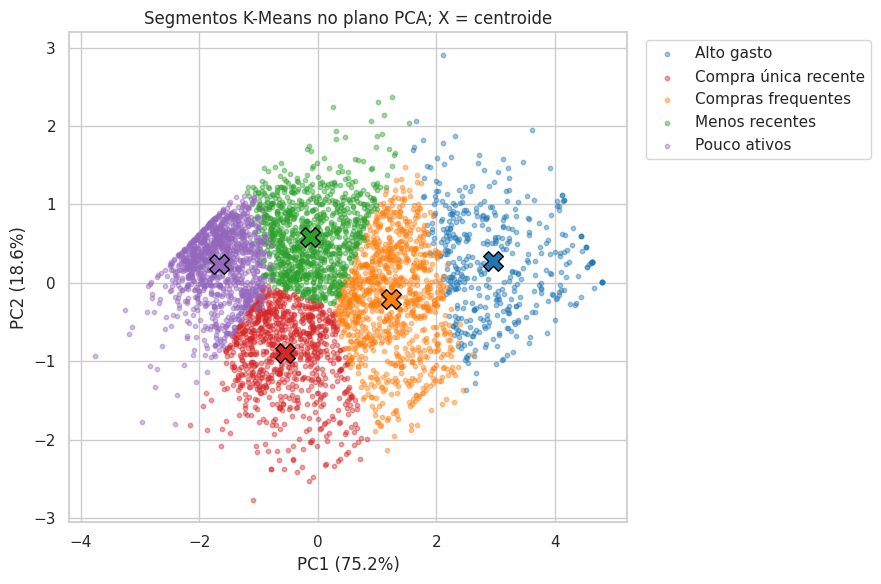

In [12]:
pca = PCA(n_components=3, random_state=SEED).fit(X)
P = pca.transform(X)
print('Variância explicada:', np.round(pca.explained_variance_ratio_, 4),
      '| PC1+PC2:', round(pca.explained_variance_ratio_[:2].sum(), 4))
pesos = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['PC1','PC2','PC3'])
display(pesos.round(3))
centros_pca = pd.DataFrame(P[:, :3], index=clientes.index,
                           columns=['PC1','PC2','PC3']).assign(
    segmento=clientes.segmento.values).groupby('segmento').mean()
paleta = dict(zip(perfil.segmento, sns.color_palette('tab10', len(perfil)).as_hex()))
fig, ax = plt.subplots(figsize=(9, 6))
for nome, grupo in clientes.assign(PC1=P[:,0], PC2=P[:,1]).groupby('segmento'):
    ax.scatter(grupo.PC1, grupo.PC2, s=10, alpha=.42, label=nome, color=paleta[nome])
for nome, row in centros_pca.iterrows():
    ax.scatter(row.PC1, row.PC2, s=200, marker='X', color=paleta[nome], edgecolor='black')
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
       title='Segmentos K-Means no plano PCA; X = centroide')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()

In [13]:
fig3d = go.Figure()
for nome, grupo in clientes.assign(PC1=P[:,0], PC2=P[:,1], PC3=P[:,2]).groupby('segmento'):
    fig3d.add_trace(go.Scatter3d(x=grupo.PC1, y=grupo.PC2, z=grupo.PC3,
        mode='markers', name=nome, marker=dict(size=2.5, opacity=.55, color=paleta[nome])))
for nome, row in centros_pca.iterrows():
    fig3d.add_trace(go.Scatter3d(x=[row.PC1], y=[row.PC2], z=[row.PC3],
        mode='markers', name=f'Centroide: {nome}', showlegend=False,
        marker=dict(size=9, symbol='diamond', color=paleta[nome],
                    line=dict(color='black', width=2))))
fig3d.update_layout(title='PCA 3D — 100% da variância das três variáveis padronizadas',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    height=650, margin=dict(l=0,r=0,b=0,t=45))
fig3d.show()

## 9. Outros gráficos dos grupos

O radar compara os grupos numa escala de 0 a 1. No heatmap, azul indica média abaixo da média geral e vermelho acima. Os valores reais estão na tabela da seção 7.

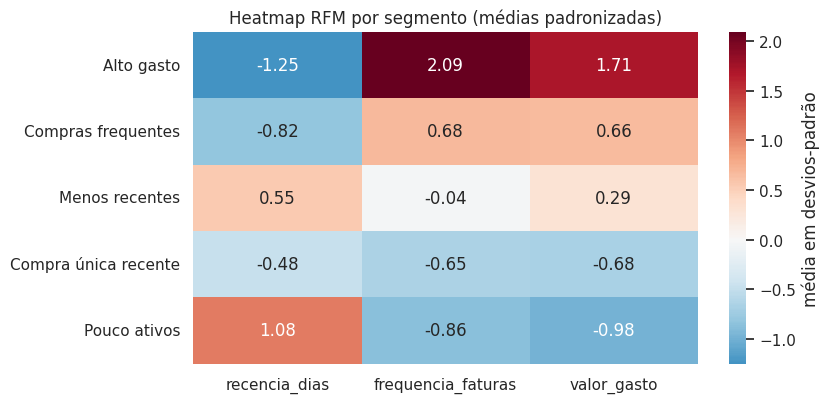

In [14]:
medianas = clientes.groupby('segmento')[FEATURES].median().loc[perfil.segmento]
radar_base = pd.DataFrame({
    'atividade recente': -medianas.recencia_dias,
    'frequência': medianas.frequencia_faturas,
    'valor': medianas.valor_gasto,
}, index=medianas.index)
radar = (radar_base - radar_base.min()) / (radar_base.max() - radar_base.min())
eixos = list(radar.columns)
fig_radar = go.Figure()
for nome, row in radar.iterrows():
    valores = row.tolist() + [row.iloc[0]]
    fig_radar.add_trace(go.Scatterpolar(r=valores, theta=eixos+[eixos[0]],
        fill='toself', name=nome))
fig_radar.update_layout(title='Perfil relativo dos segmentos (0 a 1)',
    polar=dict(radialaxis=dict(range=[0,1], visible=True)), height=550)
fig_radar.show()

media_z = pd.DataFrame(X, index=clientes.index, columns=FEATURES).assign(
    segmento=clientes.segmento.values).groupby('segmento').mean().loc[perfil.segmento]
plt.figure(figsize=(8.5, 4.2))
sns.heatmap(media_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label':'média em desvios-padrão'})
plt.title('Heatmap RFM por segmento (médias padronizadas)')
plt.xlabel(''); plt.ylabel(''); plt.tight_layout(); plt.show()

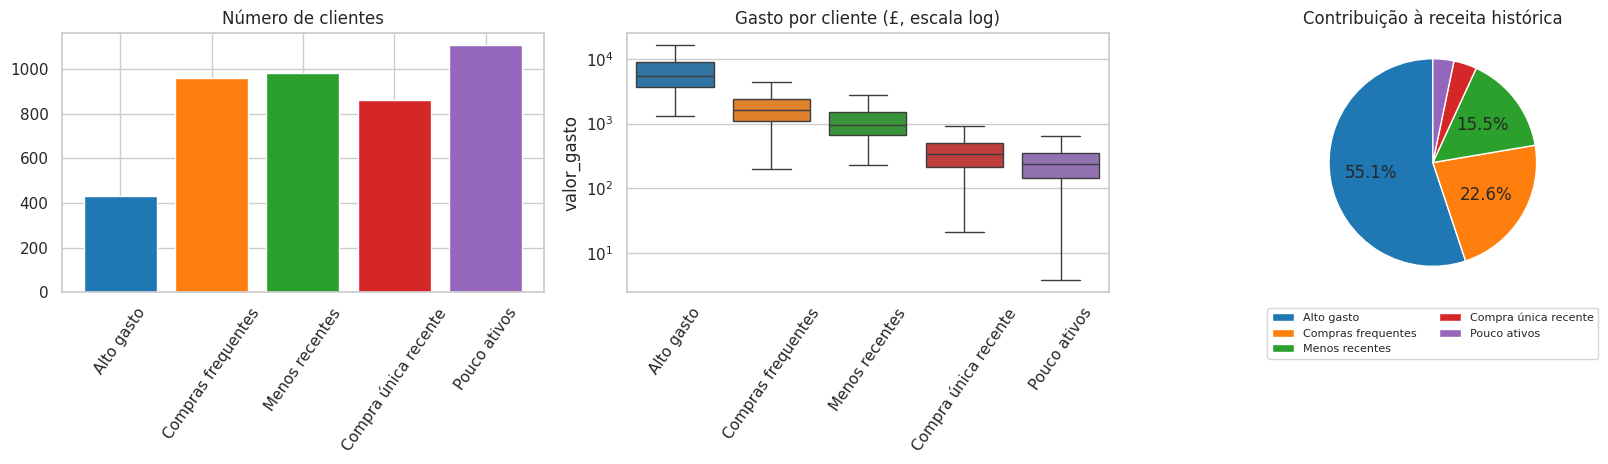

In [15]:
ordem = perfil.segmento.tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].bar(ordem, perfil.clientes.values, color=[paleta[n] for n in ordem])
axes[0].set_title('Número de clientes'); axes[0].tick_params(axis='x', rotation=55)
sns.boxplot(data=clientes.reset_index(), x='segmento', y='valor_gasto',
            order=ordem, ax=axes[1], showfliers=False, hue='segmento', legend=False,
            palette=paleta)
axes[1].set_yscale('log'); axes[1].set_title('Gasto por cliente (£, escala log)')
axes[1].tick_params(axis='x', rotation=55); axes[1].set_xlabel('')
fatias, _, _ = axes[2].pie(
    perfil.receita_total, labels=None,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 5 else '',
    colors=[paleta[n] for n in ordem], startangle=90)
axes[2].set_title('Contribuição à receita histórica')
axes[2].legend(fatias, ordem, loc='upper center', bbox_to_anchor=(.5, -.04),
               ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

## 10. Painel

No gráfico interativo, passe o mouse para ver os totais por grupo.

In [16]:
painel = make_subplots(rows=1, cols=2,
    specs=[[{'type':'xy'}, {'type':'domain'}]],
    subplot_titles=('Clientes por segmento', 'Participação na receita histórica'))
painel.add_trace(go.Bar(x=ordem, y=perfil.clientes, marker_color=[paleta[n] for n in ordem],
    text=[f'{x:,}' for x in perfil.clientes], textposition='outside', showlegend=False), row=1,col=1)
painel.add_trace(go.Pie(labels=ordem, values=perfil.receita_total,
    marker_colors=[paleta[n] for n in ordem], hole=.35,
    hovertemplate='%{label}<br>£%{value:,.0f}<br>%{percent}<extra></extra>',
    showlegend=True), row=1,col=2)
painel.update_layout(title='Painel RFM — UCI Online Retail', height=600,
    margin=dict(t=100,b=130,l=50,r=50))
painel.update_xaxes(tickangle=35, row=1,col=1)
painel.show()

## 11. Relatório executivo

### Resumo

Depois da limpeza, ficaram **397.884 linhas de compra**, de **4.338 clientes**. Elas somam **£8,91 milhões** no período analisado. O grupo **Alto gasto** tem 431 clientes (9,9% da base) e concentra 55,1% desse valor. Já **Pouco ativos** tem 1.106 clientes (25,5%) e responde por 3,3%. Essa diferença é importante para decidir onde vale testar uma campanha.

As três ações que eu avaliaria primeiro são: manter contato com o grupo de alto gasto, testar uma campanha pequena para o grupo menos recente e trabalhar a segunda compra de quem fez apenas uma compra recente. O resultado de cada teste precisa ser medido antes de ampliar a campanha.

### Método

Usei a base [Online Retail da UCI](https://archive.ics.uci.edu/dataset/352/online+retail), que registra produtos por fatura. Removi cancelamentos, compras sem identificação de cliente e linhas com quantidade ou preço não positivos. A data de referência para recência foi **10/12/2011**, um dia após a última transação da base. Frequência é o número de faturas diferentes e valor é a soma de `Quantity × UnitPrice` por cliente.

Para calcular distâncias, apliquei `log1p`, limite no percentil 99 e padronização nas três variáveis. Comparei K-Means (2 a 8 grupos), hierárquico (Ward, complete e average) e DBSCAN. Olhei silhueta, Davies–Bouldin, Calinski–Harabasz, tempo de execução e tamanho dos grupos. A maior silhueta no K-Means foi com **2 grupos (0,429)**, mas mantive **5 grupos (0,318)** porque a divisão mostrou comportamentos mais diferentes para a decisão de marketing. Nas dez inicializações testadas, o ARI mediano em relação à solução final foi **0,974**. Ward com cinco grupos teve silhueta **0,269**. O DBSCAN criou quatro grupos e deixou **5,7%** dos clientes como ruído na configuração mostrada.

### Grupos e ações possíveis

| Grupo | Clientes | Recência mediana | Faturas (mediana) | Gasto mediano | % da receita |
|---|---:|---:|---:|---:|---:|
| Alto gasto | 431 | 8 dias | 13 | £5.396 | 55,1% |
| Compras frequentes | 959 | 18 dias | 5 | £1.615 | 22,6% |
| Menos recentes | 981 | 89 dias | 3 | £954 | 15,5% |
| Compra única recente | 861 | 27 dias | 1 | £342 | 3,6% |
| Pouco ativos | 1.106 | 219 dias | 1 | £235 | 3,3% |

Para **Alto gasto**, faz sentido testar atendimento e benefícios que incentivem a continuidade sem oferecer desconto a todos. **Compras frequentes** podem receber recomendações de produtos relacionados. Em **Menos recentes**, eu faria um teste de reativação com um grupo sem mensagem para comparar. **Compra única recente** pode receber um lembrete ou sugestão após a primeira compra. Para **Pouco ativos**, começaria com contato de baixo custo.

Essas ações são hipóteses. A base informa compras, mas não traz margem, custo das campanhas ou compras depois de dezembro de 2011. Também há atacadistas entre os clientes, o que pode explicar parte da concentração do valor. Portanto, os grupos ajudam a organizar testes; sozinhos, não mostram se uma campanha dará lucro.

**Fonte:** Chen, D. (2015). *Online Retail*. UCI Machine Learning Repository. [DOI 10.24432/C5BW33](https://doi.org/10.24432/C5BW33).